# AI-Powered Multimodal ICU Early Warning System

## Attention-Based Deep Learning Framework for Early Patient Deterioration Prediction

### Objective

Develop a Multimodal BiLSTM + Attention based Deep Learning model capable of predicting whether an ICU patient will deteriorate within the next 12 hours using hourly physiological measurements, laboratory values and patient metadata.

Dataset:
Hospital Deterioration Dataset (Kaggle)


### Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Set Random Seed

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("Seed Fixed:", SEED)

Seed Fixed: 42


### Load Datset

In [4]:
DATA_PATH = "/Users/gunupatibhuvan/MyFiles/multimodal-icu-ews/data/raw/hospital_deterioration_hourly_panel.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Dataset Shape

In [5]:
print("Shape of Dataset")

print(df.shape)

Shape of Dataset
(417866, 28)


#### First 5 Rows

In [6]:
df.head()

,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,...,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour,deterioration_next_12h
0,1,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0
1,1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0
2,1,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0
3,1,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0
4,1,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,...,24,M,2,Elective,0.2173,17,0,0,-1,0


#### Last 5 Rows

In [7]:
df.tail()

,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,...,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour,deterioration_next_12h
417861,10000,24,89.82,20.65,95.46,36.43,122.05,70.56,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0
417862,10000,25,92.38,20.80,95.30,36.46,124.08,72.08,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0
417863,10000,26,94.65,21.43,94.39,36.43,123.59,71.41,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0
417864,10000,27,95.72,21.23,94.90,36.46,121.17,70.60,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0
417865,10000,28,93.46,20.76,94.83,36.42,119.53,71.02,none,0.0,...,62,F,1,ED,0.2059,29,0,0,-1,0


##### Column Names

In [8]:
print("Columns:")

for col in df.columns:

    print(col)

Columns:
patient_id
hour_from_admission
heart_rate
respiratory_rate
spo2_pct
temperature_c
systolic_bp
diastolic_bp
oxygen_device
oxygen_flow
mobility_score
nurse_alert
wbc_count
lactate
creatinine
crp_level
hemoglobin
sepsis_risk_score
age
gender
comorbidity_index
admission_type
baseline_risk_score
los_hours
deterioration_event
deterioration_within_12h_from_admission
deterioration_hour
deterioration_next_12h


##### Data Types

In [9]:
df.dtypes

patient_id                                   int64
hour_from_admission                          int64
heart_rate                                 float64
respiratory_rate                           float64
spo2_pct                                   float64
temperature_c                              float64
systolic_bp                                float64
diastolic_bp                               float64
oxygen_device                               object
oxygen_flow                                float64
mobility_score                               int64
nurse_alert                                  int64
wbc_count                                  float64
lactate                                    float64
creatinine                                 float64
crp_level                                  float64
hemoglobin                                 float64
sepsis_risk_score                          float64
age                                          int64
gender                         

### Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417866 entries, 0 to 417865
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   patient_id                               417866 non-null  int64  
 1   hour_from_admission                      417866 non-null  int64  
 2   heart_rate                               417866 non-null  float64
 3   respiratory_rate                         417866 non-null  float64
 4   spo2_pct                                 417866 non-null  float64
 5   temperature_c                            417866 non-null  float64
 6   systolic_bp                              417866 non-null  float64
 7   diastolic_bp                             417866 non-null  float64
 8   oxygen_device                            417866 non-null  object 
 9   oxygen_flow                              417866 non-null  float64
 10  mobility_score                  

### Statistical Summary

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,417866.0,4978.444200,2889.197834,1.0000,2454.0000,4986.00000,7485.0000,10000.0000
hour_from_admission,417866.0,24.098240,16.935515,0.0000,10.0000,21.00000,36.0000,71.0000
heart_rate,417866.0,89.258118,21.127257,40.0000,76.9200,86.33000,96.8600,180.0000
respiratory_rate,417866.0,20.177237,6.849362,8.0000,15.8600,19.33000,23.0400,45.0000
spo2_pct,417866.0,93.504918,5.950330,70.0000,92.5100,94.83000,96.8500,100.0000
temperature_c,417866.0,36.968563,0.451594,35.2400,36.7000,36.92000,37.1500,40.5000
systolic_bp,417866.0,113.398465,17.107426,70.0000,103.9800,114.83000,124.8500,184.5600
diastolic_bp,417866.0,70.516530,10.670383,40.0000,65.0200,71.47000,77.4400,110.0000
oxygen_flow,417866.0,7.967031,16.248186,0.0000,0.0000,0.00000,0.7000,56.1900
mobility_score,417866.0,2.283012,0.925933,0.0000,2.0000,2.00000,3.0000,4.0000


### Missing values

In [12]:
missing = df.isnull().sum()

missing

patient_id                                 0
hour_from_admission                        0
heart_rate                                 0
respiratory_rate                           0
spo2_pct                                   0
temperature_c                              0
systolic_bp                                0
diastolic_bp                               0
oxygen_device                              0
oxygen_flow                                0
mobility_score                             0
nurse_alert                                0
wbc_count                                  0
lactate                                    0
creatinine                                 0
crp_level                                  0
hemoglobin                                 0
sepsis_risk_score                          0
age                                        0
gender                                     0
comorbidity_index                          0
admission_type                             0
baseline_r

#### Duplicate Rows

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


#### Unique Patterns

In [14]:
print("Unique Patients")

print(df.patient_id.nunique())

Unique Patients
10000


#### Rows Per Patient

In [15]:
rows = df.groupby("patient_id").size()

rows.describe()

count    10000.00000
mean        41.78660
std         17.59729
min         12.00000
25%         26.00000
50%         42.00000
75%         57.00000
max         72.00000
dtype: float64

### Sequence Length Distribution

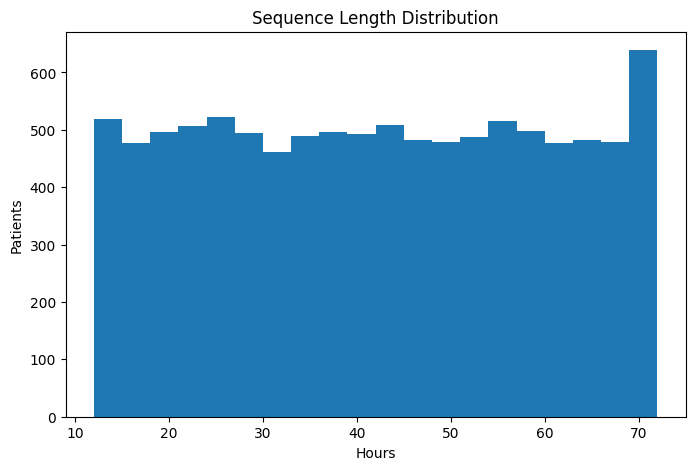

In [16]:
plt.figure(figsize=(8,5))

plt.hist(rows,bins=20)

plt.title("Sequence Length Distribution")

plt.xlabel("Hours")

plt.ylabel("Patients")

plt.show()

### Target Distribution

deterioration_next_12h
0    395277
1     22589
Name: count, dtype: int64


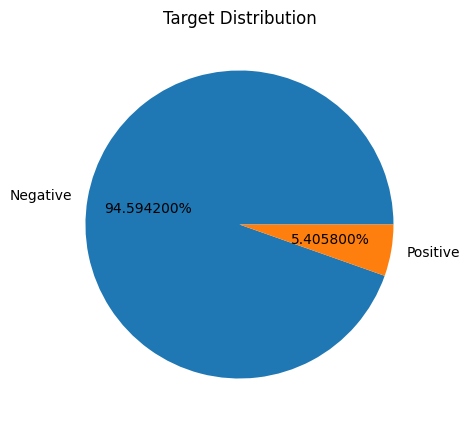

In [17]:
target = df["deterioration_next_12h"].value_counts()

print(target)

plt.figure(figsize=(5,5))

plt.pie(
    target.values,
    labels=["Negative","Positive"],
    autopct="%f%%"
)

plt.title("Target Distribution")

plt.show()

#### Patient Age Distribution

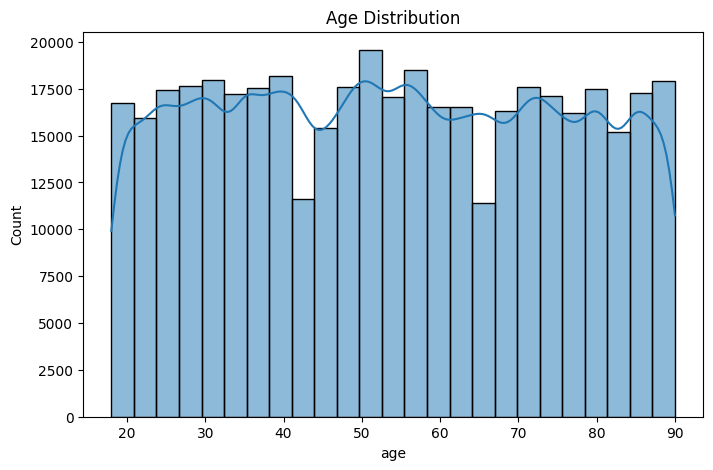

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=25,
    kde=True
)

plt.title("Age Distribution")

plt.show()

#### Gender Distribution 

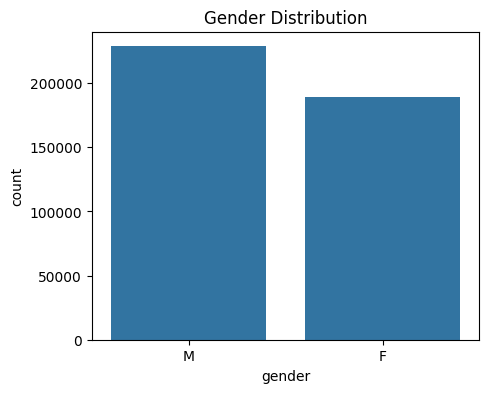

In [19]:
plt.figure(figsize=(5,4))

sns.countplot(
    x="gender",
    data=df
)

plt.title("Gender Distribution")

plt.show()

#### Admission Type Distribution 

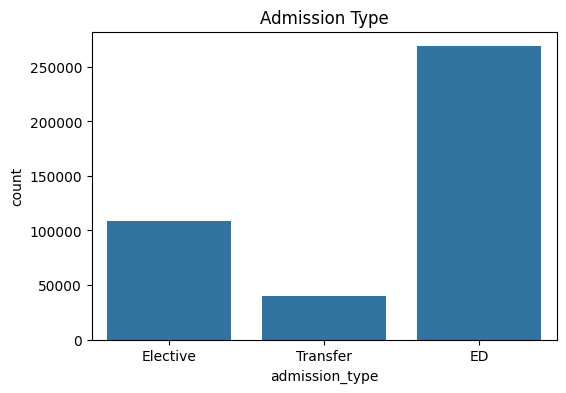

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="admission_type",
    data=df
)

plt.title("Admission Type")

plt.show()

#### Oxygen Device DIstribution 

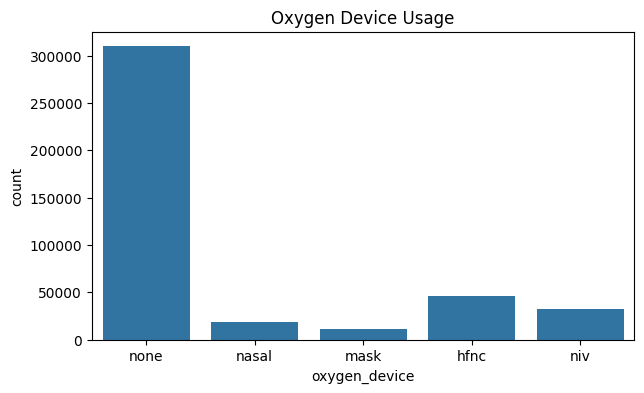

In [21]:
plt.figure(figsize=(7,4))

sns.countplot(
    x="oxygen_device",
    data=df
)

plt.title("Oxygen Device Usage")

plt.show()

#### Heart Rate DIstribution

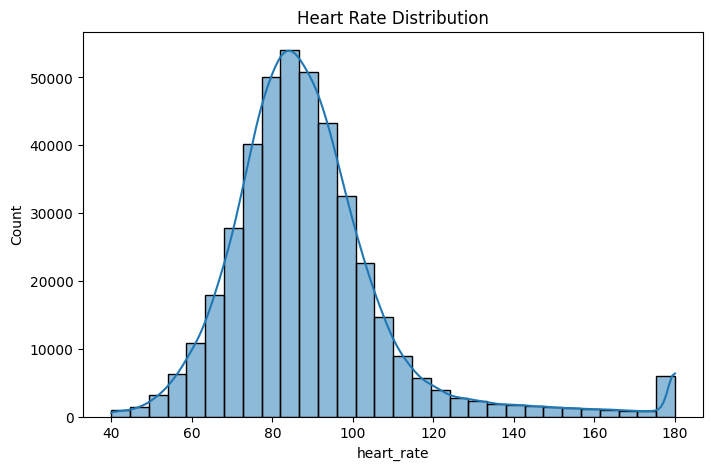

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["heart_rate"],
    bins=30,
    kde=True
)

plt.title("Heart Rate Distribution")

plt.show()

#### SpO₂ Distribution

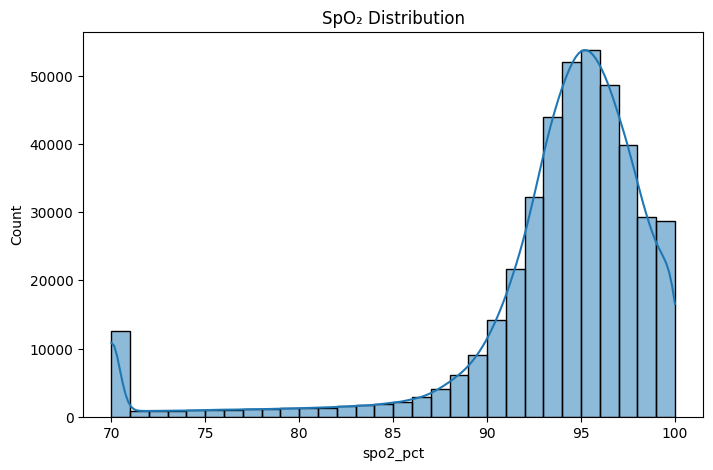

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["spo2_pct"],
    bins=30,
    kde=True
)

plt.title("SpO₂ Distribution")

plt.show()

#### Temperature Distribution

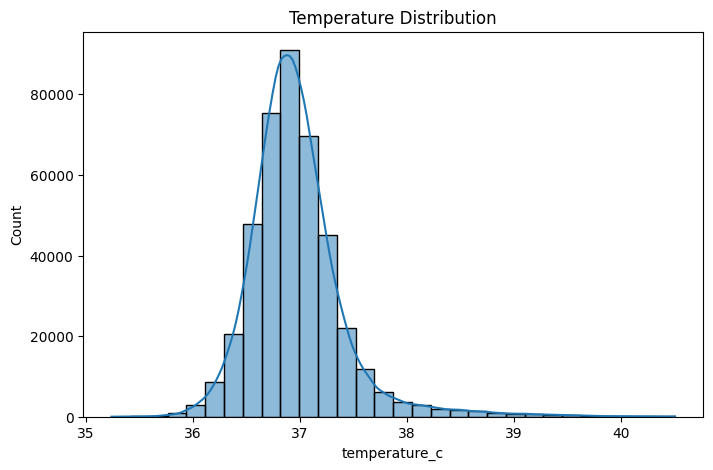

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["temperature_c"],
    bins=30,
    kde=True
)

plt.title("Temperature Distribution")

plt.show()

## Correlation Heatmap

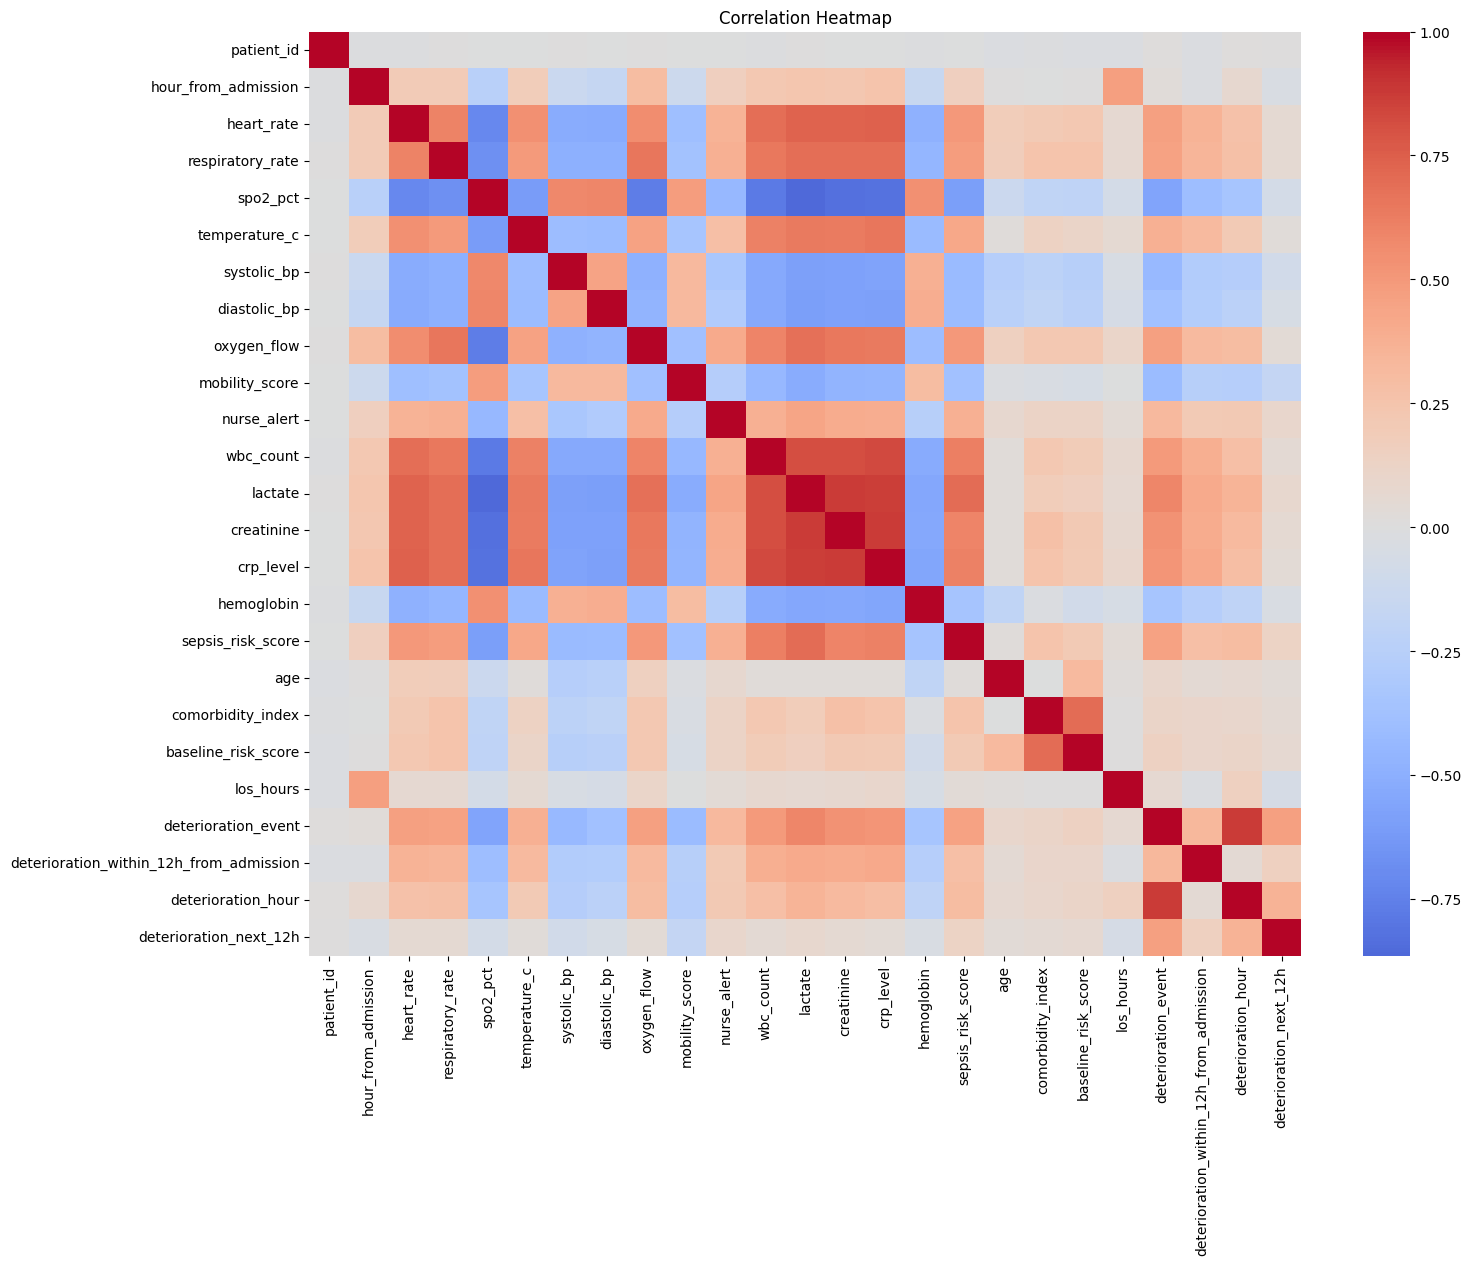

In [25]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

## Inference
Patients with elevated inflammatory markers tend to simultaneously exhibit elevated lactate, creatinine, and CRP levels, indicating that these laboratory features often worsen together during clinical deterioration.

Patients with increased heart rate generally have increased respiratory rate and require higher oxygen support, which is clinically consistent with respiratory distress or systemic illness.

Lower oxygen saturation is associated with worsening physiological status. As SpO₂ decreases, patients tend to have higher heart rate, respiratory rate, inflammatory markers, and oxygen requirements.

This is expected in critically ill ICU patients.
##### Takeaway: 
The correlation analysis indicates clinically meaningful relationships among the physiological and laboratory variables. Inflammatory biomarkers (WBC count, lactate, creatinine, and CRP) exhibit strong positive correlations, while oxygen saturation demonstrates negative correlations with several severity indicators such as heart rate, respiratory rate, and oxygen support. Baseline risk score is positively associated with comorbidity burden, and blood pressure measurements show expected positive relationships. The target-related variables are highly correlated with one another, confirming that only deterioration_next_12h should be retained as the prediction target to prevent information leakage. Overall, the absence of widespread extreme correlations among predictors suggests that the selected features provide complementary information, making them well suited for a multimodal deep learning model.

### Copy Dataset

In [26]:
df_processed = df.copy()

print("Working Copy Created")

Working Copy Created


### Encode Categorical Features

In [27]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    "gender",
    "admission_type",
    "oxygen_device"
]

encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    df_processed[column] = encoder.fit_transform(
        df_processed[column]
    )

    encoders[column] = encoder

print("Categorical Encoding Completed")

Categorical Encoding Completed


Converts text categories (e.g., "Male", "Female") into numeric labels (e.g., 0, 1).
Stores each encoder in the encoders dictionary so the same mapping can be reused later.

In [28]:
df_processed.sample(5,random_state=42)

,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,...,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour,deterioration_next_12h
362931,8675,64,160.51,34.45,77.80,38.61,70.00,40.05,3,50.06,...,87,0,8,0,0.7270,69,1,0,35,0
407945,9754,28,109.49,30.16,91.83,37.90,111.03,60.90,4,0.00,...,34,0,8,1,0.3062,39,1,0,32,1
139568,3302,10,76.86,13.56,96.21,37.00,128.72,90.45,4,0.00,...,37,1,2,2,0.4552,24,0,0,-1,0
321513,7675,5,95.78,15.55,94.71,36.63,115.73,77.70,4,0.00,...,89,1,0,0,0.5418,34,0,0,-1,0
212339,5064,2,88.23,26.26,93.51,36.70,88.46,65.91,4,0.00,...,64,1,6,0,0.7953,20,0,0,-1,0


### Feature Groups

In [29]:
TEMPORAL_FEATURES = [

    "heart_rate",
    "respiratory_rate",
    "spo2_pct",
    "temperature_c",
    "systolic_bp",
    "diastolic_bp",
    "oxygen_device",
    "oxygen_flow",
    "mobility_score",
    "nurse_alert",
    "wbc_count",
    "lactate",
    "creatinine",
    "crp_level",
    "hemoglobin",
    "sepsis_risk_score"

]

STATIC_FEATURES = [

    "age",
    "gender",
    "comorbidity_index",
    "admission_type",
    "baseline_risk_score",
    "los_hours"

]

TARGET = "deterioration_next_12h"

print("Temporal Features :",len(TEMPORAL_FEATURES))
print("Static Features :",len(STATIC_FEATURES))

Temporal Features : 16
Static Features : 6


### Normalize Numerical Features

In [30]:
from sklearn.preprocessing import StandardScaler

exclude_columns = [
    "patient_id",
    "hour_from_admission",
    TARGET
]

numerical_columns = [

    column
    for column in df_processed.columns
    if column not in exclude_columns

]

scaler = StandardScaler()

df_processed[numerical_columns] = scaler.fit_transform(
    df_processed[numerical_columns]
)

print("Normalization Completed")

Normalization Completed


In [31]:
df_processed.head()

,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,...,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour,deterioration_next_12h
0,1,0,-0.978742,-0.833252,0.506709,0.468202,-0.260616,0.741630,0.514826,-0.490334,...,-1.425641,0.909356,-0.769231,0.823219,-1.341742,-2.013816,-0.515904,-0.171373,-0.449806,0
1,1,1,-1.052107,-0.920851,0.241177,0.623209,-0.097529,0.808170,0.514826,-0.490334,...,-1.425641,0.909356,-0.769231,0.823219,-1.341742,-2.013816,-0.515904,-0.171373,-0.449806,0
2,1,2,-0.956496,-0.809892,0.158829,0.711784,-0.112142,0.781929,0.514826,-0.490334,...,-1.425641,0.909356,-0.769231,0.823219,-1.341742,-2.013816,-0.515904,-0.171373,-0.449806,0
3,1,3,-0.955550,-0.840552,0.278150,0.667497,-0.158906,0.587934,0.514826,-0.490334,...,-1.425641,0.909356,-0.769231,0.823219,-1.341742,-2.013816,-0.515904,-0.171373,-0.449806,0
4,1,4,-0.752967,-0.665353,0.390749,0.534634,-0.176442,0.464227,0.514826,-0.490334,...,-1.425641,0.909356,-0.769231,0.823219,-1.341742,-2.013816,-0.515904,-0.171373,-0.449806,0


### Train / Validation / Test Patient Split

In [32]:
patient_ids = df_processed.patient_id.unique()

train_patients, test_patients = train_test_split(

    patient_ids,
    test_size=0.15,
    random_state=42

)

train_patients, val_patients = train_test_split(

    train_patients,
    test_size=0.1765,
    random_state=42

)

### Verify Patient Counts

In [33]:
print("Training Patients :",len(train_patients))
print("Validation Patients :",len(val_patients))
print("Testing Patients :",len(test_patients))

Training Patients : 6999
Validation Patients : 1501
Testing Patients : 1500


### Create datasets 

In [34]:
train_df = df_processed[df_processed.patient_id.isin(train_patients)]
val_df   = df_processed[df_processed.patient_id.isin(val_patients)]
test_df  = df_processed[df_processed.patient_id.isin(test_patients)]

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

#Verify No Data Leakage
print(f"Train ∩ Test: {len(set(train_patients) & set(test_patients))}")
print(f"Train ∩ Validation: {len(set(train_patients) & set(val_patients))}")
print(f"Test ∩ Validation: {len(set(test_patients) & set(val_patients))}")

Train shape: (292200, 28)
Validation shape: (62932, 28)
Test shape: (62734, 28)
Train ∩ Test: 0
Train ∩ Validation: 0
Test ∩ Validation: 0


### Save Processed Dataset

In [35]:
import os
os.makedirs("processed_data", exist_ok=True)

train_df.to_csv("processed_data/train.csv", index=False)
val_df.to_csv("processed_data/val.csv", index=False)
test_df.to_csv("processed_data/test.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


#### Distribution of positive and negative patients

In [45]:
positive = train_df[train_df[TARGET]==1]
print(positive.shape)
negative = train_df[train_df[TARGET]==0]
print(negative.shape)

(15613, 28)
(276587, 28)


## Deep Learning Model Development

In [48]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence
)

print("PyTorch Imported Successfully")

PyTorch Imported Successfully


### Device Configuration

In [50]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_SEQ_LEN = 72

print("Device:", DEVICE)

Device: cpu


### Dataset + Loaders

In [51]:
class MultimodalICUDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.patient_ids = df.patient_id.unique()

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        pid = self.patient_ids[idx]
        patient = self.df[self.df.patient_id == pid].sort_values("hour_from_admission")

        temporal = patient[TEMPORAL_FEATURES].values.astype(np.float32)
        static = patient.iloc[0][STATIC_FEATURES].values.astype(np.float32)
        label = patient[TARGET].max()
        seq_len = len(temporal)

        if seq_len < MAX_SEQ_LEN:
            pad = np.zeros((MAX_SEQ_LEN - seq_len, temporal.shape[1]), np.float32)
            temporal = np.vstack((temporal, pad))
        else:
            temporal = temporal[:MAX_SEQ_LEN]

        return (
            torch.tensor(temporal),
            torch.tensor(static),
            torch.tensor(label),
            torch.tensor(seq_len),
        )

train_loader = DataLoader(MultimodalICUDataset(train_df), batch_size=32, shuffle=True)
val_loader   = DataLoader(MultimodalICUDataset(val_df), batch_size=32)
test_loader  = DataLoader(MultimodalICUDataset(test_df), batch_size=32)

print("Datasets ready")

Datasets ready


### Attention Layer

In [53]:
class Attention(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.attn = nn.Linear(hidden, 1)

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (x * w).sum(dim=1), w

### Multimodal ICU Model

In [54]:
class MultimodalICUModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(16, 64, batch_first=True, bidirectional=True)
        self.attn = Attention(128)

        self.static_net = nn.Sequential(
            nn.Linear(6, 32), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16), nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(144, 64), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1)
        )

    def forward(self, temporal, static, seq_len):
        packed = pack_padded_sequence(
            temporal, seq_len.cpu(),
            batch_first=True, enforce_sorted=False
        )

        out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=MAX_SEQ_LEN)

        t_emb, attn = self.attn(out)
        s_emb = self.static_net(static)

        x = torch.cat([t_emb, s_emb], dim=1)
        return self.classifier(x).squeeze(1), attn


model = MultimodalICUModel().to(DEVICE)

print(model)
print("Params:", sum(p.numel() for p in model.parameters()))

MultimodalICUModel(
  (lstm): LSTM(16, 64, batch_first=True, bidirectional=True)
  (attn): Attention(
    (attn): Linear(in_features=128, out_features=1, bias=True)
  )
  (static_net): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=144, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Params: 52210


#### Forward Test

In [62]:
temporal, static, label, seq_len = next(iter(train_loader))

temporal = temporal.float().to(DEVICE)
static = static.float().to(DEVICE)
seq_len = seq_len.to(DEVICE)

output, attention = model(temporal, static, seq_len)

print(output.shape)
print(attention.shape)

torch.Size([32])
torch.Size([32, 72, 1])


#### Loss Function and Optimizer 

In [56]:
criterion = nn.BCEWithLogitsLoss()
print(criterion)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(optimizer)

BCEWithLogitsLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


#### Learning Rate Scheduler

In [65]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

#### Loss Check

In [64]:
output, _ = model(temporal, static, seq_len)

loss = criterion(output, label.float().to(DEVICE))
print(loss.item())

0.7028255462646484


## Save the Model 

In [66]:
torch.save(model.state_dict(), "initial_model.pth")
print("Initial model saved")

Initial model saved


### Training and Validation Loop 

In [67]:
from sklearn.metrics import roc_auc_score
import numpy as np

best_auc = 0
patience, wait = 5, 0
history = {"train_loss": [], "val_auc": []}
#Training function
for epoch in range(20):
    model.train()
    train_loss = 0

    for temporal, static, y, seq_len in train_loader:
        temporal = temporal.float().to(DEVICE)
        static = static.float().to(DEVICE)
        y = y.float().to(DEVICE)
        seq_len = seq_len.to(DEVICE)

        optimizer.zero_grad()
        out, _ = model(temporal, static, seq_len)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    #Validation function
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for temporal, static, y, seq_len in val_loader:
            temporal = temporal.float().to(DEVICE)
            static = static.float().to(DEVICE)
            seq_len = seq_len.to(DEVICE)

            out, _ = model(temporal, static, seq_len)
            preds.extend(torch.sigmoid(out).cpu().numpy())
            trues.extend(y.numpy())

    val_auc = roc_auc_score(trues, preds)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch+1} | Loss: {train_loss:.3f} | Val AUC: {val_auc:.3f}")
    #Learning-rate scheduler
    scheduler.step(val_auc)

    if val_auc > best_auc:
        best_auc = val_auc
        wait = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        wait += 1
        #Early stopping
        if wait >= patience:
            print("Early stopping")
            break

Epoch 1 | Loss: 33.369 | Val AUC: 0.996
Epoch 2 | Loss: 10.890 | Val AUC: 0.996
Epoch 3 | Loss: 9.233 | Val AUC: 0.997
Epoch 4 | Loss: 8.878 | Val AUC: 0.998
Epoch 5 | Loss: 7.486 | Val AUC: 0.997
Epoch 6 | Loss: 7.454 | Val AUC: 0.997
Epoch 7 | Loss: 6.999 | Val AUC: 0.997
Epoch 8 | Loss: 7.027 | Val AUC: 0.997
Epoch 9 | Loss: 5.432 | Val AUC: 0.997
Early stopping


#### Training History Plot

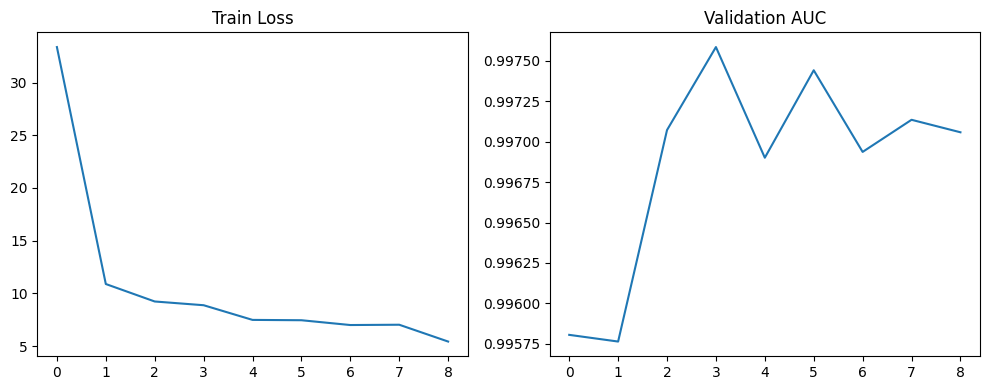

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"])
plt.title("Train Loss")

plt.subplot(1,2,2)
plt.plot(history["val_auc"])
plt.title("Validation AUC")

plt.tight_layout()
plt.show()

### Load Best Model

In [68]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("Best model loaded")

Best model loaded


### Test Evaluation

In [69]:
preds, trues = [], []

with torch.no_grad():
    for temporal, static, y, seq_len in test_loader:
        temporal = temporal.float().to(DEVICE)
        static = static.float().to(DEVICE)
        seq_len = seq_len.to(DEVICE)

        out, _ = model(temporal, static, seq_len)

        preds.extend(torch.sigmoid(out).cpu().numpy())
        trues.extend(y.numpy())

### Metrics

In [70]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

binary_preds = (np.array(preds) > 0.5).astype(int)

print("Accuracy:", accuracy_score(trues, binary_preds))
print("Precision:", precision_score(trues, binary_preds))
print("Recall:", recall_score(trues, binary_preds))
print("F1:", f1_score(trues, binary_preds))
print("ROC-AUC:", roc_auc_score(trues, preds))

Accuracy: 0.986
Precision: 0.9691780821917808
Recall: 0.9593220338983051
F1: 0.9642248722316865
ROC-AUC: 0.9981686475842184


### Classification Report

In [77]:
from sklearn.metrics import classification_report

print(classification_report(trues, binary_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1205
           1       0.97      0.96      0.96       295

    accuracy                           0.99      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.99      0.99      0.99      1500



### Confusion Matrix

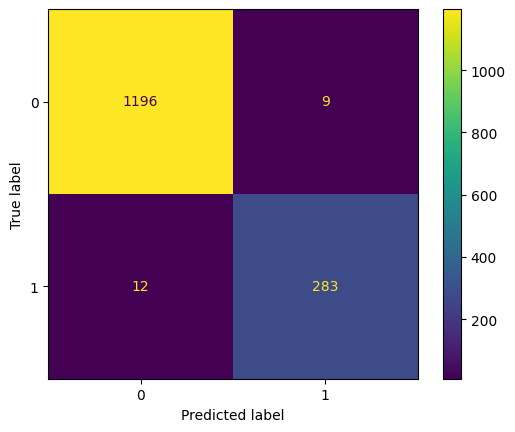

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(trues, binary_preds)
ConfusionMatrixDisplay(cm).plot()
plt.show()

### ROC + PR Curve

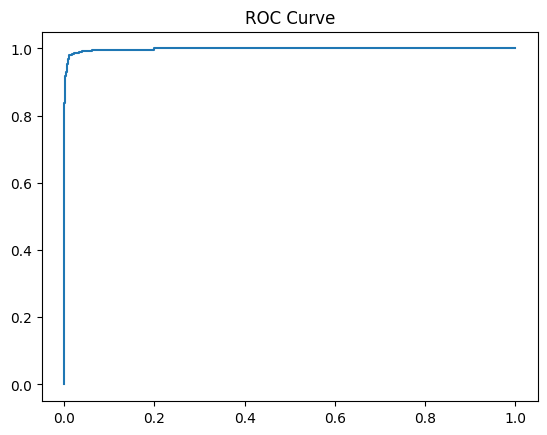

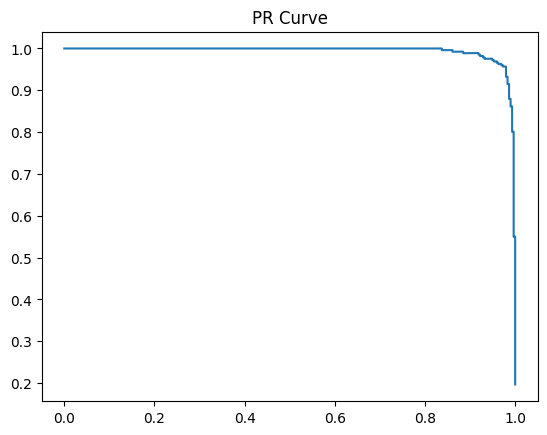

In [72]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(trues, preds)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

p, r, _ = precision_recall_curve(trues, preds)
plt.plot(r, p)
plt.title("PR Curve")
plt.show()

### Attention Visualization

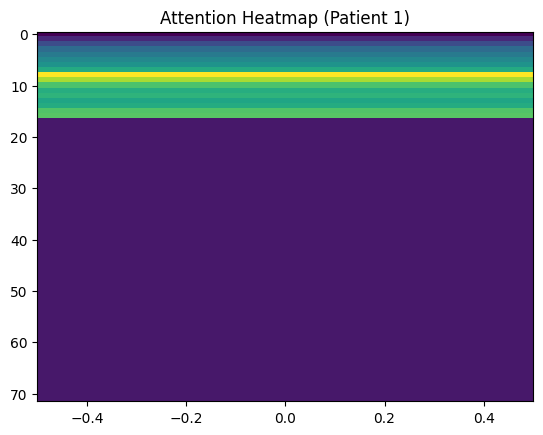

In [73]:
temporal, static, y, seq_len = next(iter(test_loader))
temporal = temporal.float().to(DEVICE)
static = static.float().to(DEVICE)
seq_len = seq_len.to(DEVICE)

_, attn = model(temporal, static, seq_len)

plt.imshow(attn[0].detach().cpu().numpy(), aspect="auto")
plt.title("Attention Heatmap (Patient 1)")
plt.show()

In [79]:
temporal, static, y, seq_len = next(iter(test_loader))

temporal = temporal.float().to(DEVICE)
static = static.float().to(DEVICE)
seq_len = seq_len.to(DEVICE)

output, attention = model(temporal, static, seq_len)

print("Prediction:", torch.sigmoid(output[:5]))

Prediction: tensor([8.6580e-04, 1.3559e-04, 1.3582e-04, 4.6940e-05, 3.3568e-04],
       grad_fn=<SigmoidBackward0>)


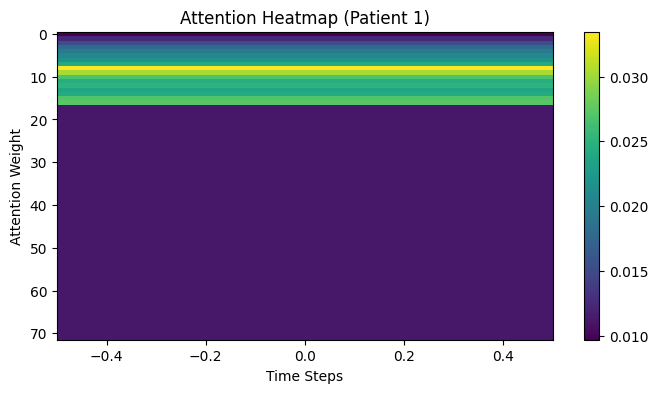

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.imshow(attention[0].detach().cpu().numpy(), aspect="auto")
plt.title("Attention Heatmap (Patient 1)")
plt.xlabel("Time Steps")
plt.ylabel("Attention Weight")
plt.colorbar()
plt.show()

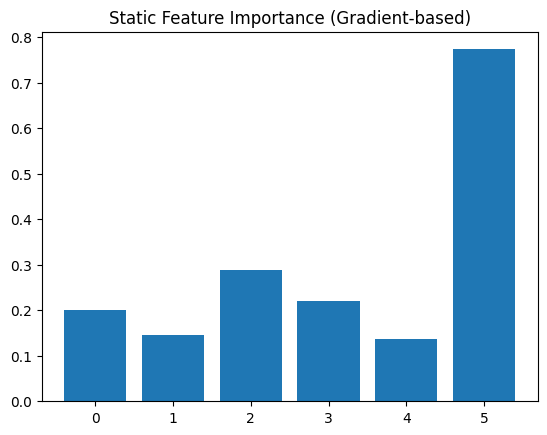

In [81]:
static.requires_grad = True

out, _ = model(temporal, static, seq_len)
out.sum().backward()

importance = static.grad.abs().mean(dim=0)

plt.bar(range(len(importance)), importance.cpu().numpy())
plt.title("Static Feature Importance (Gradient-based)")
plt.show()

In [84]:
import torch

class CaptumWrappedModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, temporal, static):
        # create seq_len automatically
        seq_len = torch.full(
            (temporal.size(0),),
            temporal.size(1),
            device=temporal.device
        )
        out, _ = self.model(temporal, static, seq_len)
        return out

from captum.attr import IntegratedGradients

wrapped_model = CaptumWrappedModel(model)
ig = IntegratedGradients(wrapped_model)

attr = ig.attribute((temporal, static))
print("IG computed")

IG computed


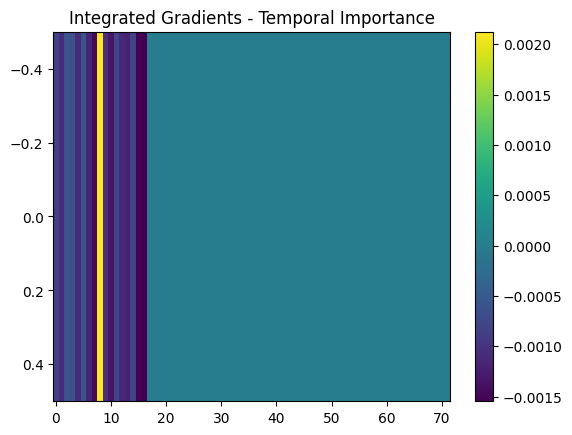

In [85]:
temporal_attr = attr[0].mean(dim=2).detach().cpu().numpy()

plt.imshow(temporal_attr[0:1], aspect="auto")
plt.title("Integrated Gradients - Temporal Importance")
plt.colorbar()
plt.show()

In [86]:
def predict_single(temporal, static, seq_len):
    model.eval()
    with torch.no_grad():
        out, attn = model(
            temporal.float().to(DEVICE),
            static.float().to(DEVICE),
            seq_len.to(DEVICE)
        )
        prob = torch.sigmoid(out).cpu().numpy()
        return prob, attn

In [87]:
prob, attn = predict_single(temporal, static, seq_len)

print("ICU Risk Probability:", prob[:5])

ICU Risk Probability: [8.6579740e-04 1.3558865e-04 1.3581562e-04 4.6940255e-05 3.3567590e-04]


In [88]:
sample = test_df.sample(1)

print("Sample patient selected")
print(sample[TARGET].values)

Sample patient selected
[0]


In [89]:
print("""
Model is ready for inference:
- Temporal patterns captured via BiLSTM
- Attention highlights important time steps
- Static features improve prediction stability
- Output = ICU risk probability
""")


Model is ready for inference:
- Temporal patterns captured via BiLSTM
- Attention highlights important time steps
- Static features improve prediction stability
- Output = ICU risk probability

